# In this model we want to do the following:
- Model the white light curve for both visits
- Use fit results to fix the ramp and breathing parameters

In [1]:
from preamble_jax import *

Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]
CPU devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]


2026-03-02 08:57:28,427 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch
/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/chromatic/imports.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import copy, pkg_resources, os, glob, pickle


🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

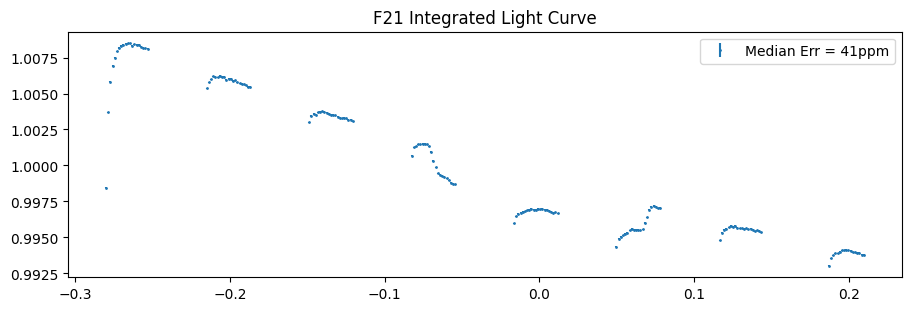

<Figure size 640x480 with 0 Axes>

In [17]:
visit = 'F21'

orbits_to_exclude = np.array([0,1,2,6,7])
lc_index = 1 if visit=='F21' else 0
bin_edges = jnp.array([0.791,1.135,1.64]) * u.micron

predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']

rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
speclc_rainbow = rainbow

binned_for_model = rainbow.bin(wavelength_edges=bin_edges)
fleck_wavelengths = binned_for_model.wavelength.value

integrated_flux = np.trapz(speclc_rainbow.flux.value,x=speclc_rainbow.wavelength.value,axis=0)

img_date = speclc_rainbow.time.value
data_flux = integrated_flux/integrated_flux.mean()
relative_err = np.sqrt(integrated_flux/speclc_rainbow.nwave)/integrated_flux
time_from_T0 = img_date - predicted_T0

plt.figure(figsize=(9,3))
plt.errorbar(time_from_T0,data_flux,relative_err*data_flux,
             label=f'Median Err = {int(np.nanmedian(relative_err)*1e6) }ppm',
            fmt='o',ms=1)
plt.legend()
plt.title(f'{visit} Integrated Light Curve')
plt.show()
plt.clf()

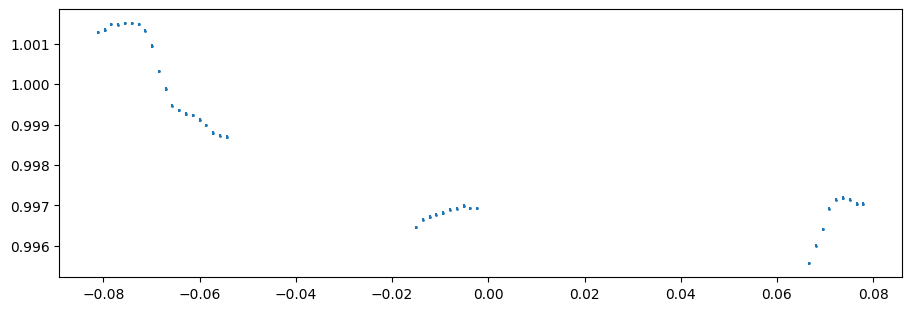

<Figure size 640x480 with 0 Axes>

In [18]:
# Label the orbits
orbit = np.zeros_like(img_date)
for j in range(len(img_date)):
    if j >= 1:
        if (img_date[j] - img_date[j - 1]) > 0.01:
            orbit[j] = (orbit[j - 1] + 1)
        else:
            orbit[j] = orbit[j - 1]

# Trim the first point from each orbit
ref_time = []
for o in np.unique(orbit):
    first_index = np.where(orbit == o)[0][0]
    ref_time.append(img_date[first_index])
    data_flux[first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
    relative_err[first_index] = np.nan
    img_date[first_index] = np.nan
    time_from_T0[first_index] = np.nan

time_from_T0[94:116] = np.nan

# Set data to nan if it was in the pre-defined list of orbits to exclude
for orbit_to_exclude in orbits_to_exclude:
    data_flux[orbit == orbit_to_exclude] = np.nan
    relative_err[orbit == orbit_to_exclude] = np.nan
    img_date[orbit == orbit_to_exclude] = np.nan
    time_from_T0[orbit == orbit_to_exclude] = np.nan

plt.figure(figsize=(9,3) )
plt.errorbar(time_from_T0,data_flux,yerr=relative_err,fmt='o',ms=1)
plt.show()
plt.clf()

# Populate ramp_phase time arrays
phase_list=[]
for o in [0,1,2,3,4,5,6,7]:
    rphase = (img_date[orbit==o] - ref_time[o]) / 0.066
    phase_list.append(rphase)
ramp_phase = np.concatenate(phase_list)
breathing_phase = ( (img_date-ref_time[0]+0.02) / 0.066 ) % 1

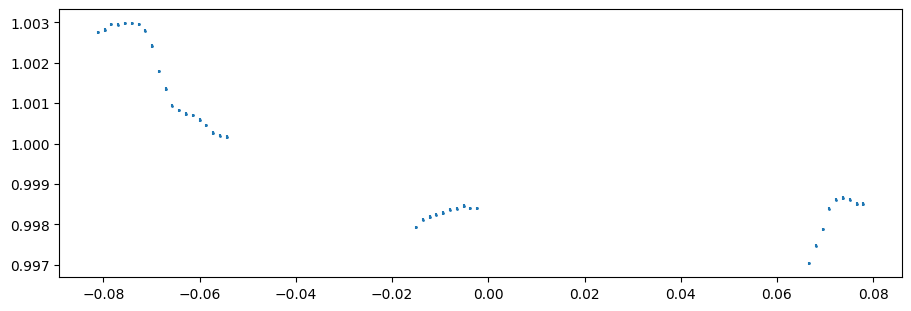

<Figure size 640x480 with 0 Axes>

In [19]:
# Convert all arrays to JAX arrays
_data_flux = jnp.array( data_flux[~np.isnan(time_from_T0)] )
data_flux = _data_flux[~jnp.isnan(_data_flux)]
_relative_err = jnp.array(relative_err[~np.isnan(time_from_T0)] )
relative_err = _relative_err[~jnp.isnan(_data_flux)]
_img_date = jnp.array(img_date[~np.isnan(time_from_T0)] )
img_date = _img_date[~jnp.isnan(_data_flux)]

ramp_phase = jnp.array(ramp_phase[~np.isnan(time_from_T0)] )
breathing_phase = jnp.array(breathing_phase[~np.isnan(time_from_T0)] )
time_from_T0 = jnp.array(time_from_T0[~np.isnan(time_from_T0)] )

normalized_data_flux = data_flux/jnp.mean(data_flux)
normalized_relative_err = relative_err*normalized_data_flux

plt.figure(figsize=(9,3) )
plt.errorbar(time_from_T0,normalized_data_flux,yerr=normalized_relative_err,fmt='o',ms=1)
plt.show()
plt.clf()

In [20]:
default_params={

    # Ramp Model Parameters
    'r_1': 12.57,
    'r_2': -6.58,
    'r_3': -0.01065,
    #Breathing params
    'b_1':0,
    'b_2':0,
    'b_3':0,
    'b_4':0,

    'baseline_slope':0,
    
    # Planet parameters
    'Mp':8.0,
    'i_planet':89.5,
    'P_orb':8.463,
    't_0':0.000605,
    'rp_rstar': 0.0465,
    'a_rstar': 19.15,
    'ecc': 0.0,
    'u_1':0.35,
    'u_2':0.15,
    
    # Stellar parameters
    'log_g':4.5,
    'i_star':89.5,
    'P_rot':4.86,
    'Rs':0.8,
    'Ms':0.6,
    'metallicity':0.0,

    # Spot Parameters
    'log_fixedspot_radii':-1.6,
    'T_unocculted': 3100,
    'T_occulted': 3500,
    'T_phot': 4100,
    'T_spot': 3500,
    'limb_spot_lon':0,#-1.305,
    'limb_spot_lat':0,#1.2,
    'limb_spot_rad':0,#0.22,
    'chord_spot_lon_1':0,#0.05,
    'chord_spot_lat_1':0,#1.54,
    'chord_spot_rad_1':0,#0.15,
    'chord_spot_lon_2':0,#0.86,
    'chord_spot_lat_2':0,#1.66,
    'chord_spot_rad_2':0,#0.055,

    # Model meta-parameters
    'beta':0.25,

}

In [21]:
def numpyro_model():

    """
    Define the probabilistic model in NUMPYRO
    """
    params = {}

    # Instrument Parameters
    params['r_1'] = numpyro.sample('r_1', dist.Uniform(0.1, 20.0))
    params['r_2'] = numpyro.sample('r_2', dist.Uniform(-9.0, -4))
    params['r_3'] = numpyro.sample('r_3', dist.Uniform(-0.02,0.05))

    # Instrument Parameters
    params['b_1'] = numpyro.sample('b_1', dist.Uniform(-1.0,1.0))
    params['b_2'] = numpyro.sample('b_2', dist.Uniform(-1.0,1.0))
    params['b_3'] = numpyro.sample('b_3', dist.Uniform(-1.0,0.15))
    params['b_4'] = numpyro.sample('b_4', dist.Uniform(-1.0,1.0))

    # Baseline Parameters
    
    params['baseline_slope'] = numpyro.sample('baseline_slope', dist.Uniform(-0.06, -0.01))
    
    params['limb_spot_lon'] = 0.0 #numpyro.sample('limb_spot_lon', dist.Uniform(-1.32, -1.26))
    params['limb_spot_lat'] = 0.0 #numpyro.sample('limb_spot_lat', dist.Uniform(0.9, 1.3))
    params['limb_spot_rad'] = 0.0 #numpyro.sample('limb_spot_rad', dist.Uniform(0.1, 0.6))

    params['chord_spot_lon_1'] = 0.0#numpyro.sample('chord_spot_lon_1', dist.Uniform(0.04, 0.09))
    params['chord_spot_lat_1'] = 0.0#numpyro.sample('chord_spot_lat_1', dist.Uniform(1.51, 1.62))
    params['chord_spot_rad_1'] = 0.0#numpyro.sample('chord_spot_rad_1', dist.Uniform(0.13, 0.27))

    params['chord_spot_lon_2'] = 0.0#numpyro.sample('chord_spot_lon_2', dist.Uniform(0.84,0.89))
    params['chord_spot_lat_2'] = 0.0#numpyro.sample('chord_spot_lat_2', dist.Uniform(1.64, 1.73))
    params['chord_spot_rad_2'] = 0.0#numpyro.sample('chord_spot_rad_2', dist.Uniform(0.04, 0.08))

    # Planet Parameters
    params['rp_rstar'] = numpyro.sample('rp_rstar', dist.Uniform(0.042, 0.052))
    params['t_0'] = numpyro.sample('t_0', dist.Uniform(-0.0006, 0.0006)) 
    params['a_rstar'] = 19.15 #numpyro.sample('a', dist.Uniform(19.0, 19.35))
    
    params['u_1'] = numpyro.sample('u_1', dist.Uniform(0.0,0.4))
    params['u_2'] = numpyro.sample('u_2', dist.Uniform(0.0,0.4))
    
    # Stellar Parameters
    params['T_phot'] = 4100
    params['T_spot'] = 3500 
    beta = numpyro.sample('beta', dist.Uniform(0.0, 0.8))

    @jit
    def broadband_transit(params,**kwargs):

        # Calculate systematics model
        ramp = ramp_model_jax(phase=ramp_phase,
                        r1=jnp.asarray(params['r_1'], dtype=jnp.float64),
                        r2=jnp.asarray(params['r_2'], dtype=jnp.float64),
                        r3=jnp.asarray(params['r_3'], dtype=jnp.float64) )
        breathing = breathing_model_jax(phase=breathing_phase,
                                  b1=jnp.asarray(params['b_1'], dtype=jnp.float64),
                                  b2=jnp.asarray(params['b_2'], dtype=jnp.float64),
                                  b3=jnp.asarray(params['b_3'], dtype=jnp.float64),
                                  b4=jnp.asarray(params['b_4'], dtype=jnp.float64))
        linear_baseline = linear_model_jax(x=time_from_T0,
                                           m=jnp.asarray(params['baseline_slope'], dtype=jnp.float64) 
                                          )
        _systematics = (breathing * ramp * linear_baseline)
        systematics = _systematics/jnp.mean(_systematics)
        
        # Update Planet Parameters
        planet_parameters = dict(
            inclination = jnp.radians(default_params['i_planet']),
            a = jnp.asarray(params['a_rstar'], dtype=jnp.float64),
            rp = jnp.asarray(params['rp_rstar'], dtype=jnp.float64),
            period = default_params['P_orb'],
            t0 = jnp.asarray(params['t_0'], dtype=jnp.float64),
            ecc = default_params['ecc'],
            u1 = jnp.asarray(params['u_1'], dtype=jnp.float64),
            u2 = jnp.asarray(params['u_2'], dtype=jnp.float64)
        )
        
        # Get spectra for the model temps
        Phot = get_binned_BTSettl_spectrum_jax(T=params['T_phot'],data_wave = fleck_wavelengths)
        Cool = get_binned_BTSettl_spectrum_jax(T=params['T_spot'],data_wave = fleck_wavelengths)
        
        # Update stellar parameters
        active_star = ActiveStar(
            times = time_from_T0,
            inclination=jnp.radians(default_params['i_star']),
            T_eff=jnp.asarray(params['T_phot'], dtype=jnp.float64),
            wavelength=Phot[0]*1e-6, # convert from micron to m
            phot=Phot[1],
            P_rot=default_params['P_rot']
        )
        
        active_star.spectrum = jnp.concatenate([
            jnp.vstack([Cool[1],
                        Cool[1],
                        Cool[1]
                       ]),
        ])
        active_star.temperature = jnp.concatenate([
            jnp.array([params['T_spot'],
                       params['T_spot'],
                       params['T_spot']
                      ]),
        ])
        active_star.lon = jnp.concatenate([
            jnp.array([params['limb_spot_lon'],
                       params['chord_spot_lon_1'],
                       params['chord_spot_lon_2']
                      ]),
        ])
        active_star.lat = jnp.concatenate([
            jnp.array([params['limb_spot_lat'],
                       params['chord_spot_lat_1'], 
                       params['chord_spot_lat_2']
                      ]),
        ])
        active_star.rad = jnp.concatenate([
            jnp.array([params['limb_spot_rad'], 
                       params['chord_spot_rad_1'], 
                       params['chord_spot_rad_2']
                      ]),
        ])        
        
        lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)        
        lc_model = lc.T[lc_index] * systematics
        mean_per_wavelength = jnp.mean(lc_model)
        normalized_model = lc_model / mean_per_wavelength
    
        return normalized_model

    numpyro.sample(
        'Obs', dist.Normal(
            loc=broadband_transit(params), 
            scale=(10**beta)*normalized_relative_err,
        ), obs=normalized_data_flux
    )

In [22]:
def plot_results(parameter_dict):
    params = parameter_dict

    # Calculate systematics model
    ramp = ramp_model_jax(phase=ramp_phase,
                    r1=jnp.asarray(params.get('r_1',default_params['r_1']), dtype=jnp.float64),
                    r2=jnp.asarray(params.get('r_2',default_params['r_2']), dtype=jnp.float64),
                    r3=jnp.asarray(params.get('r_3',default_params['r_3']), dtype=jnp.float64) )
    breathing = breathing_model_jax(phase=breathing_phase,
                              b1=jnp.asarray(params.get('b_1',default_params['b_1']), dtype=jnp.float64),
                              b2=jnp.asarray(params.get('b_2',default_params['b_2']), dtype=jnp.float64),
                              b3=jnp.asarray(params.get('b_3',default_params['b_3']), dtype=jnp.float64),
                              b4=jnp.asarray(params.get('b_4',default_params['b_4']), dtype=jnp.float64))
    linear_baseline = linear_model_jax(x=time_from_T0,
                                           m=jnp.asarray(params['baseline_slope'], dtype=jnp.float64) )
    _systematics = (breathing * ramp * linear_baseline)
    systematics = _systematics/jnp.mean(_systematics)
    
    # Update Planet Parameters
    planet_parameters = dict(
        inclination = jnp.radians(default_params['i_planet']),
        a = jnp.asarray(params.get('a_rstar',default_params['a_rstar']), dtype=jnp.float64),
        rp = jnp.asarray(params.get('rp_rstar',default_params['rp_rstar']), dtype=jnp.float64),
        period = jnp.asarray(params.get('P_orb',default_params['P_orb']), dtype=jnp.float64),
        t0 = jnp.asarray(params.get('t_0',default_params['t_0']), dtype=jnp.float64),
        ecc = jnp.asarray(params.get('ecc',default_params['ecc']), dtype=jnp.float64),
        u1 = jnp.asarray(params.get('u_1',default_params['u_1']), dtype=jnp.float64),
        u2 = jnp.asarray(params.get('u_2',default_params['u_2']), dtype=jnp.float64),
    )
    
    # Get spectra for the model temps
    Phot = get_binned_BTSettl_spectrum_jax(T=jnp.asarray(params.get('T_phot',default_params['T_phot']), dtype=jnp.float64),
                                           data_wave = fleck_wavelengths)
    Cool = get_binned_BTSettl_spectrum_jax(T=jnp.asarray(params.get('T_spot',default_params['T_spot']), dtype=jnp.float64),
                                           data_wave = fleck_wavelengths)
    
    # Update stellar parameters
    active_star = ActiveStar(
        times = time_from_T0,
        inclination = jnp.radians(default_params['i_star']),
        T_eff=jnp.asarray(params.get('T_phot',default_params['T_phot']), dtype=jnp.float64),
        wavelength=Phot[0]*1e-6, # convert from micron to m
        phot=Phot[1],
        P_rot=default_params['P_rot']
    )
    
    active_star.spectrum = jnp.concatenate([
        jnp.vstack([Cool[1],Cool[1],Cool[1]
                   ]),
    ])
    active_star.temperature = jnp.concatenate([
        jnp.array([params.get('T_spot', default_params['T_spot']),
                   params.get('T_spot', default_params['T_spot']),
                   params.get('T_spot', default_params['T_spot'])
                  ]),
    ])
    active_star.lon = jnp.concatenate([
        jnp.array([params.get('limb_spot_lon', default_params['limb_spot_lon']), 
                   params.get('chord_spot_lon_1', default_params['chord_spot_lon_1']), 
                   params.get('chord_spot_lon_2', default_params['chord_spot_lon_2']),
                   ]),
    ])
    active_star.lat = jnp.concatenate([
        jnp.array([params.get('limb_spot_lat', default_params['limb_spot_lat']), 
                   params.get('chord_spot_lat_1', default_params['chord_spot_lat_1']), 
                   params.get('chord_spot_lat_2', default_params['chord_spot_lat_2']),
                   ]),
    ])
    active_star.rad = jnp.concatenate([
        jnp.array([params.get('limb_spot_rad', default_params['limb_spot_rad']), 
                   params.get('chord_spot_rad_1', default_params['chord_spot_rad_1']), 
                   params.get('chord_spot_rad_2', default_params['chord_spot_rad_2']),
                   ]),
    ])        
    
    lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)        
    lc_model = lc.T[lc_index] * systematics
    mean_per_wavelength = jnp.mean(lc_model)
    normalized_model = lc_model / mean_per_wavelength

    return normalized_model,active_star

In [23]:
rng_seed = 0

def hstack_recursive(final_states, checkpoint_states):
    for key in final_states.keys():
        if isinstance(final_states[key], dict):
            hstack_recursive(final_states[key], checkpoint_states[key])
        else:
            final_states[key] = jnp.hstack([
                final_states[key], 
                checkpoint_states[key]
            ])

def print_big_message(big_message):
    print('\n\n')
    print('=' * len(big_message))
    print(big_message)
    print('=' * len(big_message))
    print('\n\n')

def post_batch_viz_save(self, **kwargs):
    """
    here we define some tasks to do after each completed checkpoint:
    """
    print(f'Corner for checkpoint {self.checkpoint}')

    samples_cumulative = self.get_samples()
    corner.corner(samples_cumulative)
    plt.suptitle(f'checkpoint {self.checkpoint}')
    plt.savefig(f'../../figs/chkpt_{self.checkpoint}_corner.png',dpi=200)
    plt.show()
    plt.clf()
    
    # EXTRACT MEDIAN PARAMETERS DIRECTLY FROM SAMPLES (like corner plot does)
    chkpt_median_params = {}
    for param_name, param_samples in samples_cumulative.items():
        # param_samples has shape (num_chains, num_samples)
        # Flatten across chains and compute median
        flattened_samples = param_samples.flatten()
        chkpt_median_params[param_name] = float(jnp.median(flattened_samples))
    
    print("Median parameters from samples:")
    for param, value in chkpt_median_params.items():
        print(f"  {param}: {value:.4f}")

    # result = arviz.from_numpyro(self)
    # display(arviz.summary(result))

    checkpoint_model, checkpoint_star = plot_results(chkpt_median_params)        
    
    plt.figure(figsize=(9,3))
    plt.errorbar(time_from_T0,normalized_data_flux,yerr=(10**chkpt_median_params.get('beta', default_params['beta']))*normalized_relative_err,fmt='o',ms=1,color='k')
    plt.scatter(time_from_T0,checkpoint_model,s=1,color='r')    
    plt.title(f'checkpoint {self.checkpoint} Plot')
    plt.savefig(f'../../figs/chkpt_{self.checkpoint}_model.png',dpi=200)
    plt.show()
    plt.clf()

    with open(f'../../data/samples/samples_cumulative_{self.start_time}_checkpoint_{self.checkpoint:04d}.pkl', 'wb') as file:
        pickle.dump(dict(samples_cumulative), file)

class MCMCWithCheckpoints(MCMC):
    running_states = None
    checkpoint = 0
    start_time = None
    
    def run_checkpoints(self, rng_key, *args, extra_fields=(), n_checkpoints=10, 
                        progress_bar_warmup=True, progress_bar_samples=True, 
                        init_params=None, on_checkpoint=None, **kwargs):
        """
        Run the MCMC samplers and collect samples.

        :param random.PRNGKey rng_key: Random number generator key to be used for the sampling.
            For multi-chains, a batch of `num_chains` keys can be supplied. If `rng_key`
            does not have batch_size, it will be split in to a batch of `num_chains` keys.
        :param args: Arguments to be provided to the :meth:`numpyro.infer.mcmc.MCMCKernel.init` method.
            These are typically the arguments needed by the `model`.
        :param extra_fields: Extra fields (aside from `"z"`, `"diverging"`) from the
            state object (e.g. :data:`numpyro.infer.hmc.HMCState` for HMC) to be collected
            during the MCMC run. Note that subfields can be accessed using dots, e.g.
            `"adapt_state.step_size"` can be used to collect step sizes at each step. Exclude sample sites from
            collection with "~`sampler.sample_field`.`sample_site`". e.g. "~z.a" will prevent site "a" from
            being collected if you're using the NUTS sampler. To collect samples of a site "a" in the
            unconstrained space, we can specify the variable here, e.g. `extra_fields=("z.a",)`.
        :type extra_fields: tuple or list of str
        :param init_params: Initial parameters to begin sampling. The type must be consistent
            with the input type to `potential_fn` provided to the kernel. If the kernel is
            instantiated by a numpyro model, the initial parameters here correspond to latent
            values in unconstrained space.
        :param kwargs: Keyword arguments to be provided to the :meth:`numpyro.infer.mcmc.MCMCKernel.init`
            method. These are typically the keyword arguments needed by the `model`.

        .. note:: jax allows python code to continue even when the compiled code has not finished yet.
            This can cause troubles when trying to profile the code for speed.
            See https://jax.readthedocs.io/en/latest/async_dispatch.html and
            https://jax.readthedocs.io/en/latest/profiling.html for pointers on profiling jax programs.
        """
        self.start_time = datetime.now().strftime("%Y-%m-%d_%H-%M")
        num_warmup_total = int(self.num_warmup)
        num_samples_total = int(self.num_samples)
        
        check_point_indices = [
            jnp.arange(num_warmup_total), 
            *jnp.array_split(jnp.arange(num_samples_total), n_checkpoints)
        ]
        n_checkpoints = len(check_point_indices)
        rng_keys = random.split(rng_key, n_checkpoints)
        pbar = tqdm(enumerate(zip(rng_keys, check_point_indices)), total=n_checkpoints)
        for checkpoint, (rng_key, bounds) in pbar:
            if checkpoint == 0:
                self.progress_bar = progress_bar_warmup
                pbar.set_description('Run warmup')
                print_big_message("Begin warmup")
                self.warmup(rng_key, *args, extra_fields=extra_fields, init_params=init_params, **kwargs)
                print_big_message(f"Begin {num_samples_total} samples with {n_checkpoints} checkpoints")

            else:
                pbar.set_description(f'Run samples {bounds.min()} to {bounds.max()}')

                self.progress_bar = progress_bar_samples
                self.num_samples = bounds.size
                self.run(rng_key, *args, extra_fields=extra_fields, init_params=init_params, **kwargs)

                # add to running states:
                if self.running_states is None:
                    self.running_states = dict(self._states)
                else:
                    hstack_recursive(self.running_states, self._states)
                
                # ensure that calls to `self.get_samples` will build a new samples array
                # out of the running states:
                self._states_flat = None
                self._states = self.running_states

                if on_checkpoint is not None:
                    on_checkpoint(self, **kwargs)
                self.checkpoint += 1
        
        pbar.close()

        # reset to total number for arviz IO
        self.num_samples = num_samples_total

In [24]:
from datetime import datetime
current_date = datetime.now().strftime("%Y_%m_%d")

n_temps = 1
n_spots = 0
n_warmup = 1_000
n_samples = 8_000
n_chains = 8
n_check=2

# model_designation = f'{visit}_{n_samples}samples_{n_chains}chains_whitelight_linear_{current_date}_forspotcomparison'
model_designation = f'{visit}_{n_samples}samples_{n_chains}chains_whitelight_linear_2025_12_24'

rng_key = PRNGKey(40)

# sampler = NUTS(
#     numpyro_model,
#     dense_mass= [('r_1','r_2','r_3','b_1','b_2','b_3','b_4','baseline_slope'),('u_1','u_2')]
# )
# mcmc = MCMCWithCheckpoints(
#     sampler, 
#     num_warmup=n_warmup, 
#     num_samples=n_samples,
#     num_chains=n_chains
# )

# mcmc.run_checkpoints(rng_key, n_checkpoints=n_check, on_checkpoint=post_batch_viz_save)

# mcmc.print_summary()                                                                        

# result = arviz.from_numpyro(mcmc)

In [25]:
'Save the result'
result = arviz.from_netcdf(f'../../data/samples/{model_designation}')
'Print the summary'
arviz.summary(result)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b_1,-0.059,0.022,-0.098,-0.018,0.001,0.000,759.0,579.0,1.01
b_2,0.184,0.065,0.061,0.301,0.002,0.001,665.0,617.0,1.02
b_3,-0.214,0.085,-0.369,-0.057,0.003,0.002,611.0,533.0,1.02
b_4,0.091,0.040,0.015,0.164,0.002,0.001,588.0,544.0,1.02
baseline_slope,-0.031,0.000,-0.031,-0.030,0.000,0.000,13778.0,21803.0,1.00
beta,0.137,0.048,0.050,0.230,0.000,0.000,19616.0,22645.0,1.00
r_1,12.624,2.373,8.171,17.105,0.022,0.015,11729.0,8873.0,1.00
r_2,-6.575,0.108,-6.777,-6.378,0.001,0.001,15540.0,14307.0,1.00
r_3,-0.010,0.001,-0.011,-0.009,0.000,0.000,20396.0,25718.0,1.00
rp_rstar,0.049,0.000,0.049,0.049,0.000,0.000,17064.0,27481.0,1.00


/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(
/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/arviz/stats/stats.py:1057: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/numpy/core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


Computed from 64000 posterior samples and 52 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   444.46     4.49
p_loo       11.71        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       52  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

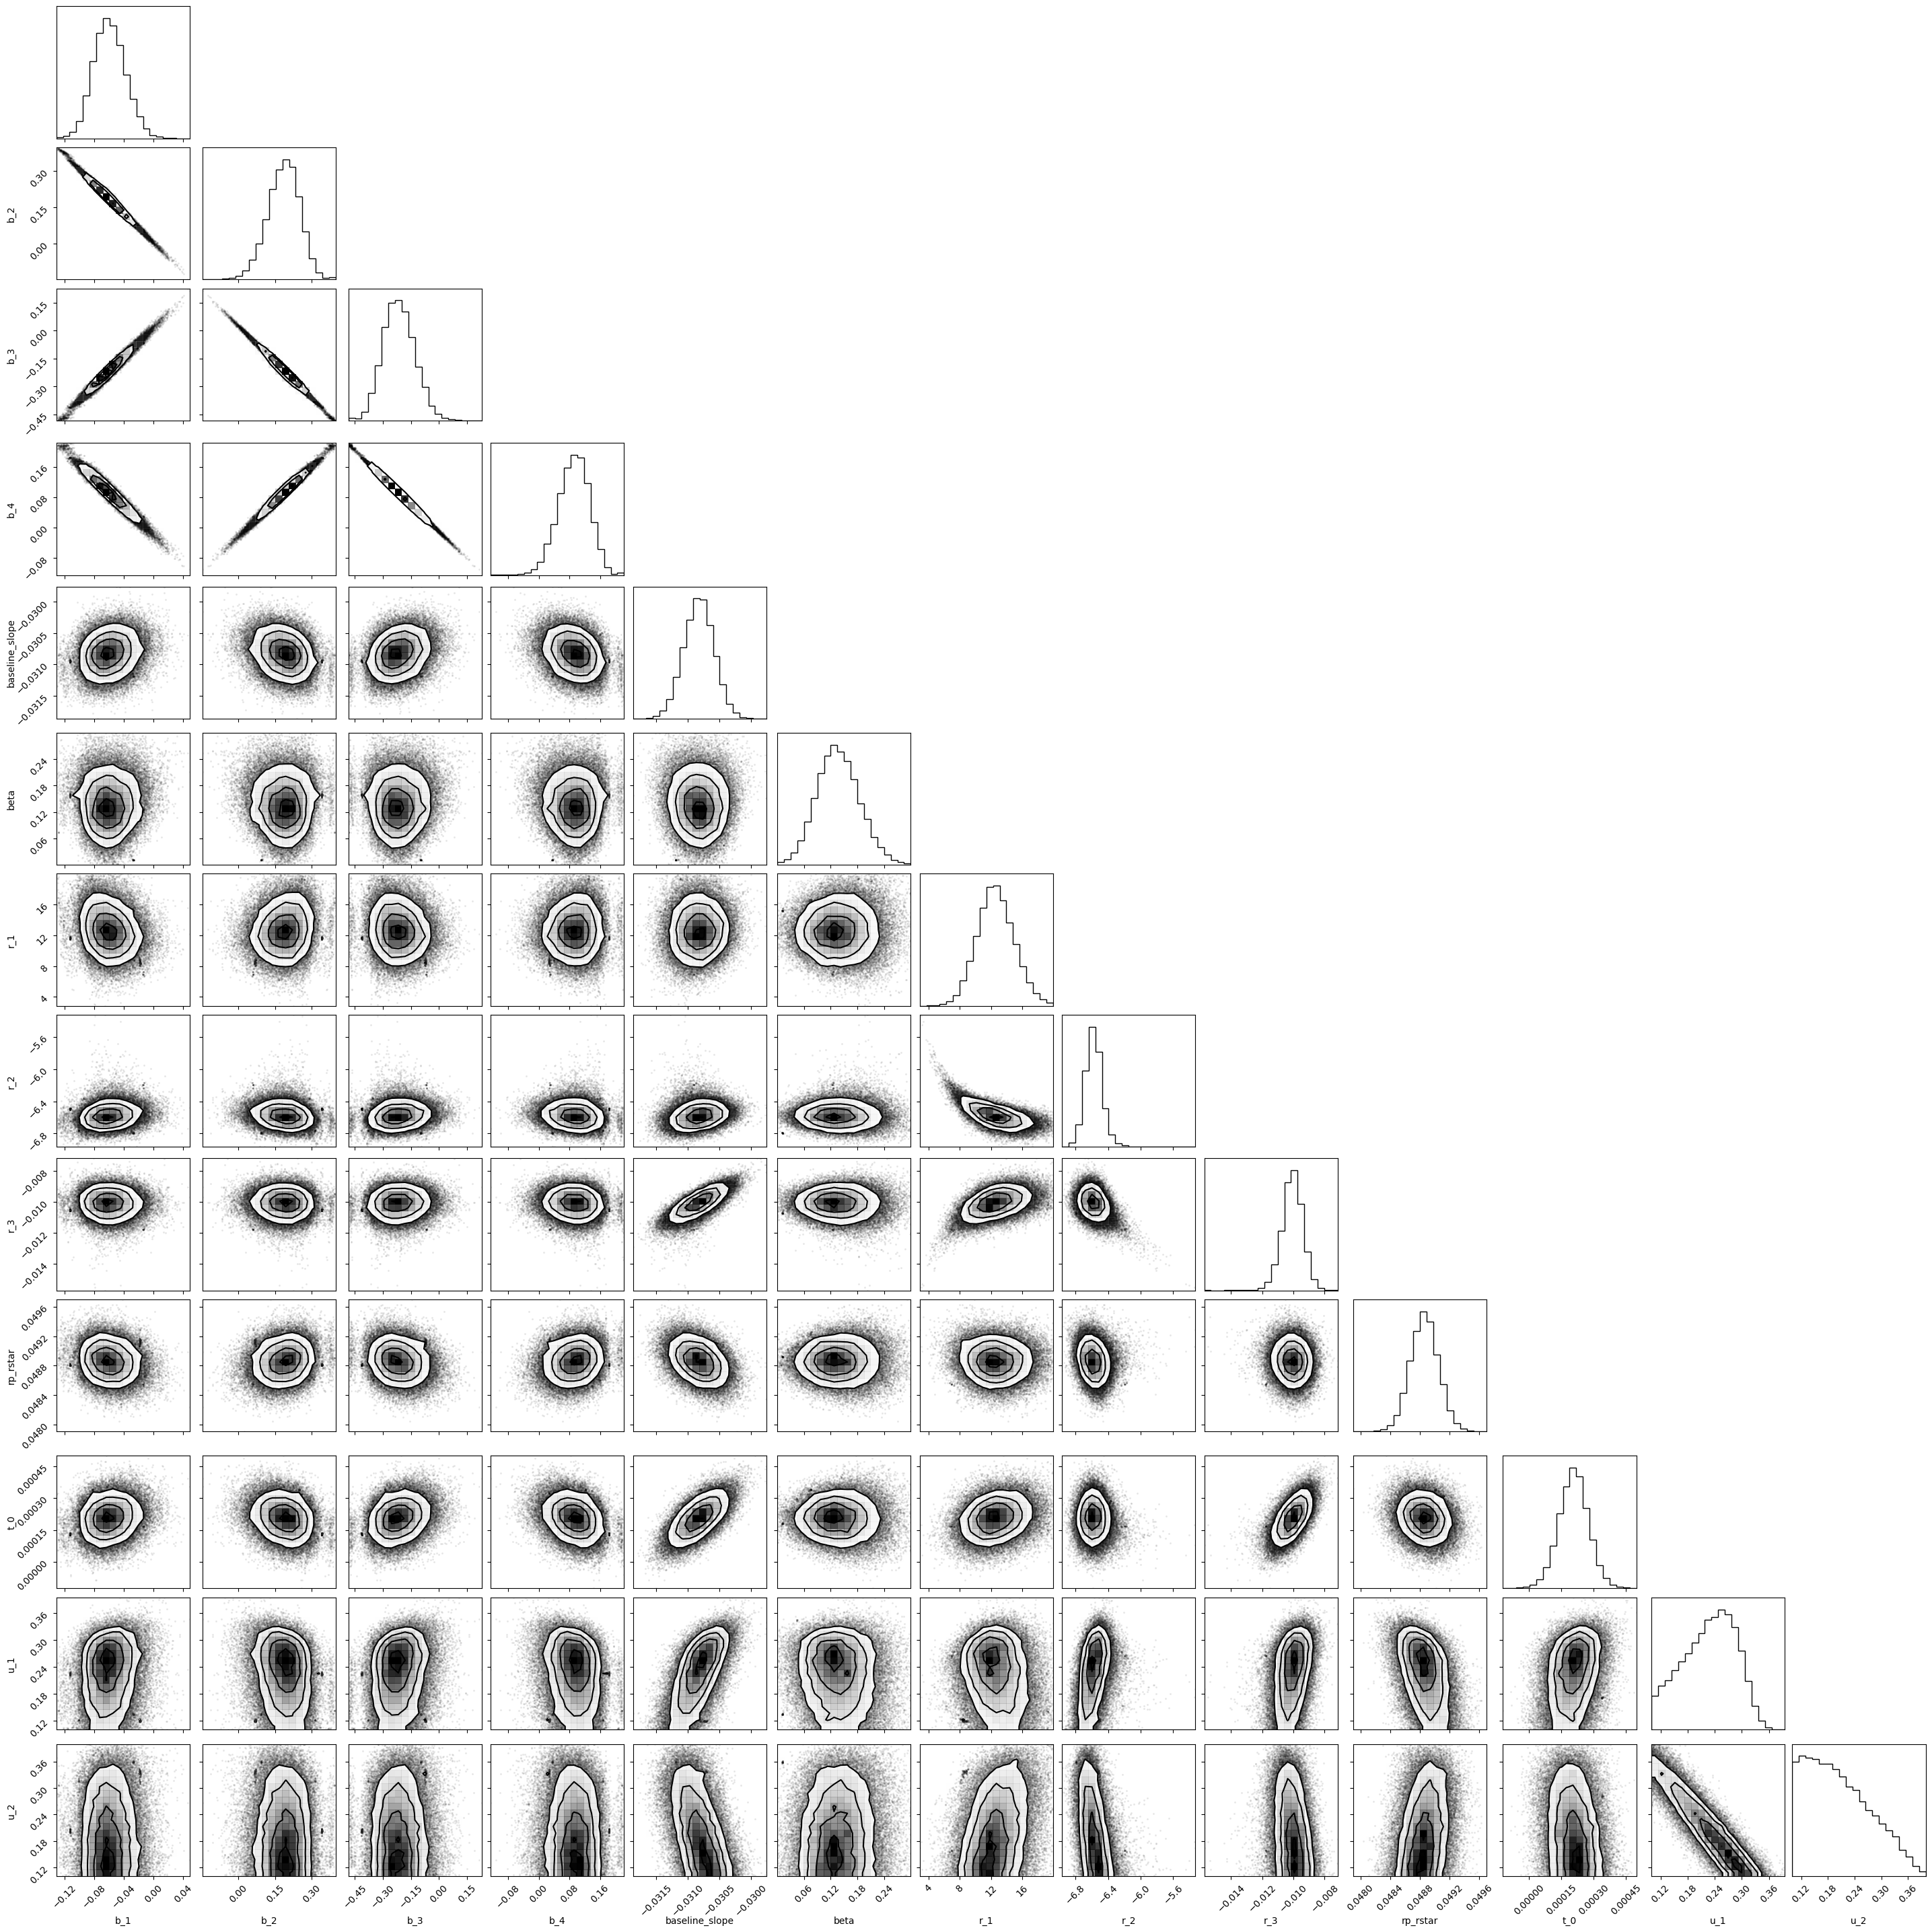

In [26]:
'Make a corner plot'
corner.corner(
    result, 
)
plt.savefig(f'../../figs/{model_designation}_corner.png',dpi=200)

'Examine the Leave-One-Out (LOO) summary'
loo = arviz.loo(result, pointwise=True)
loo

/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


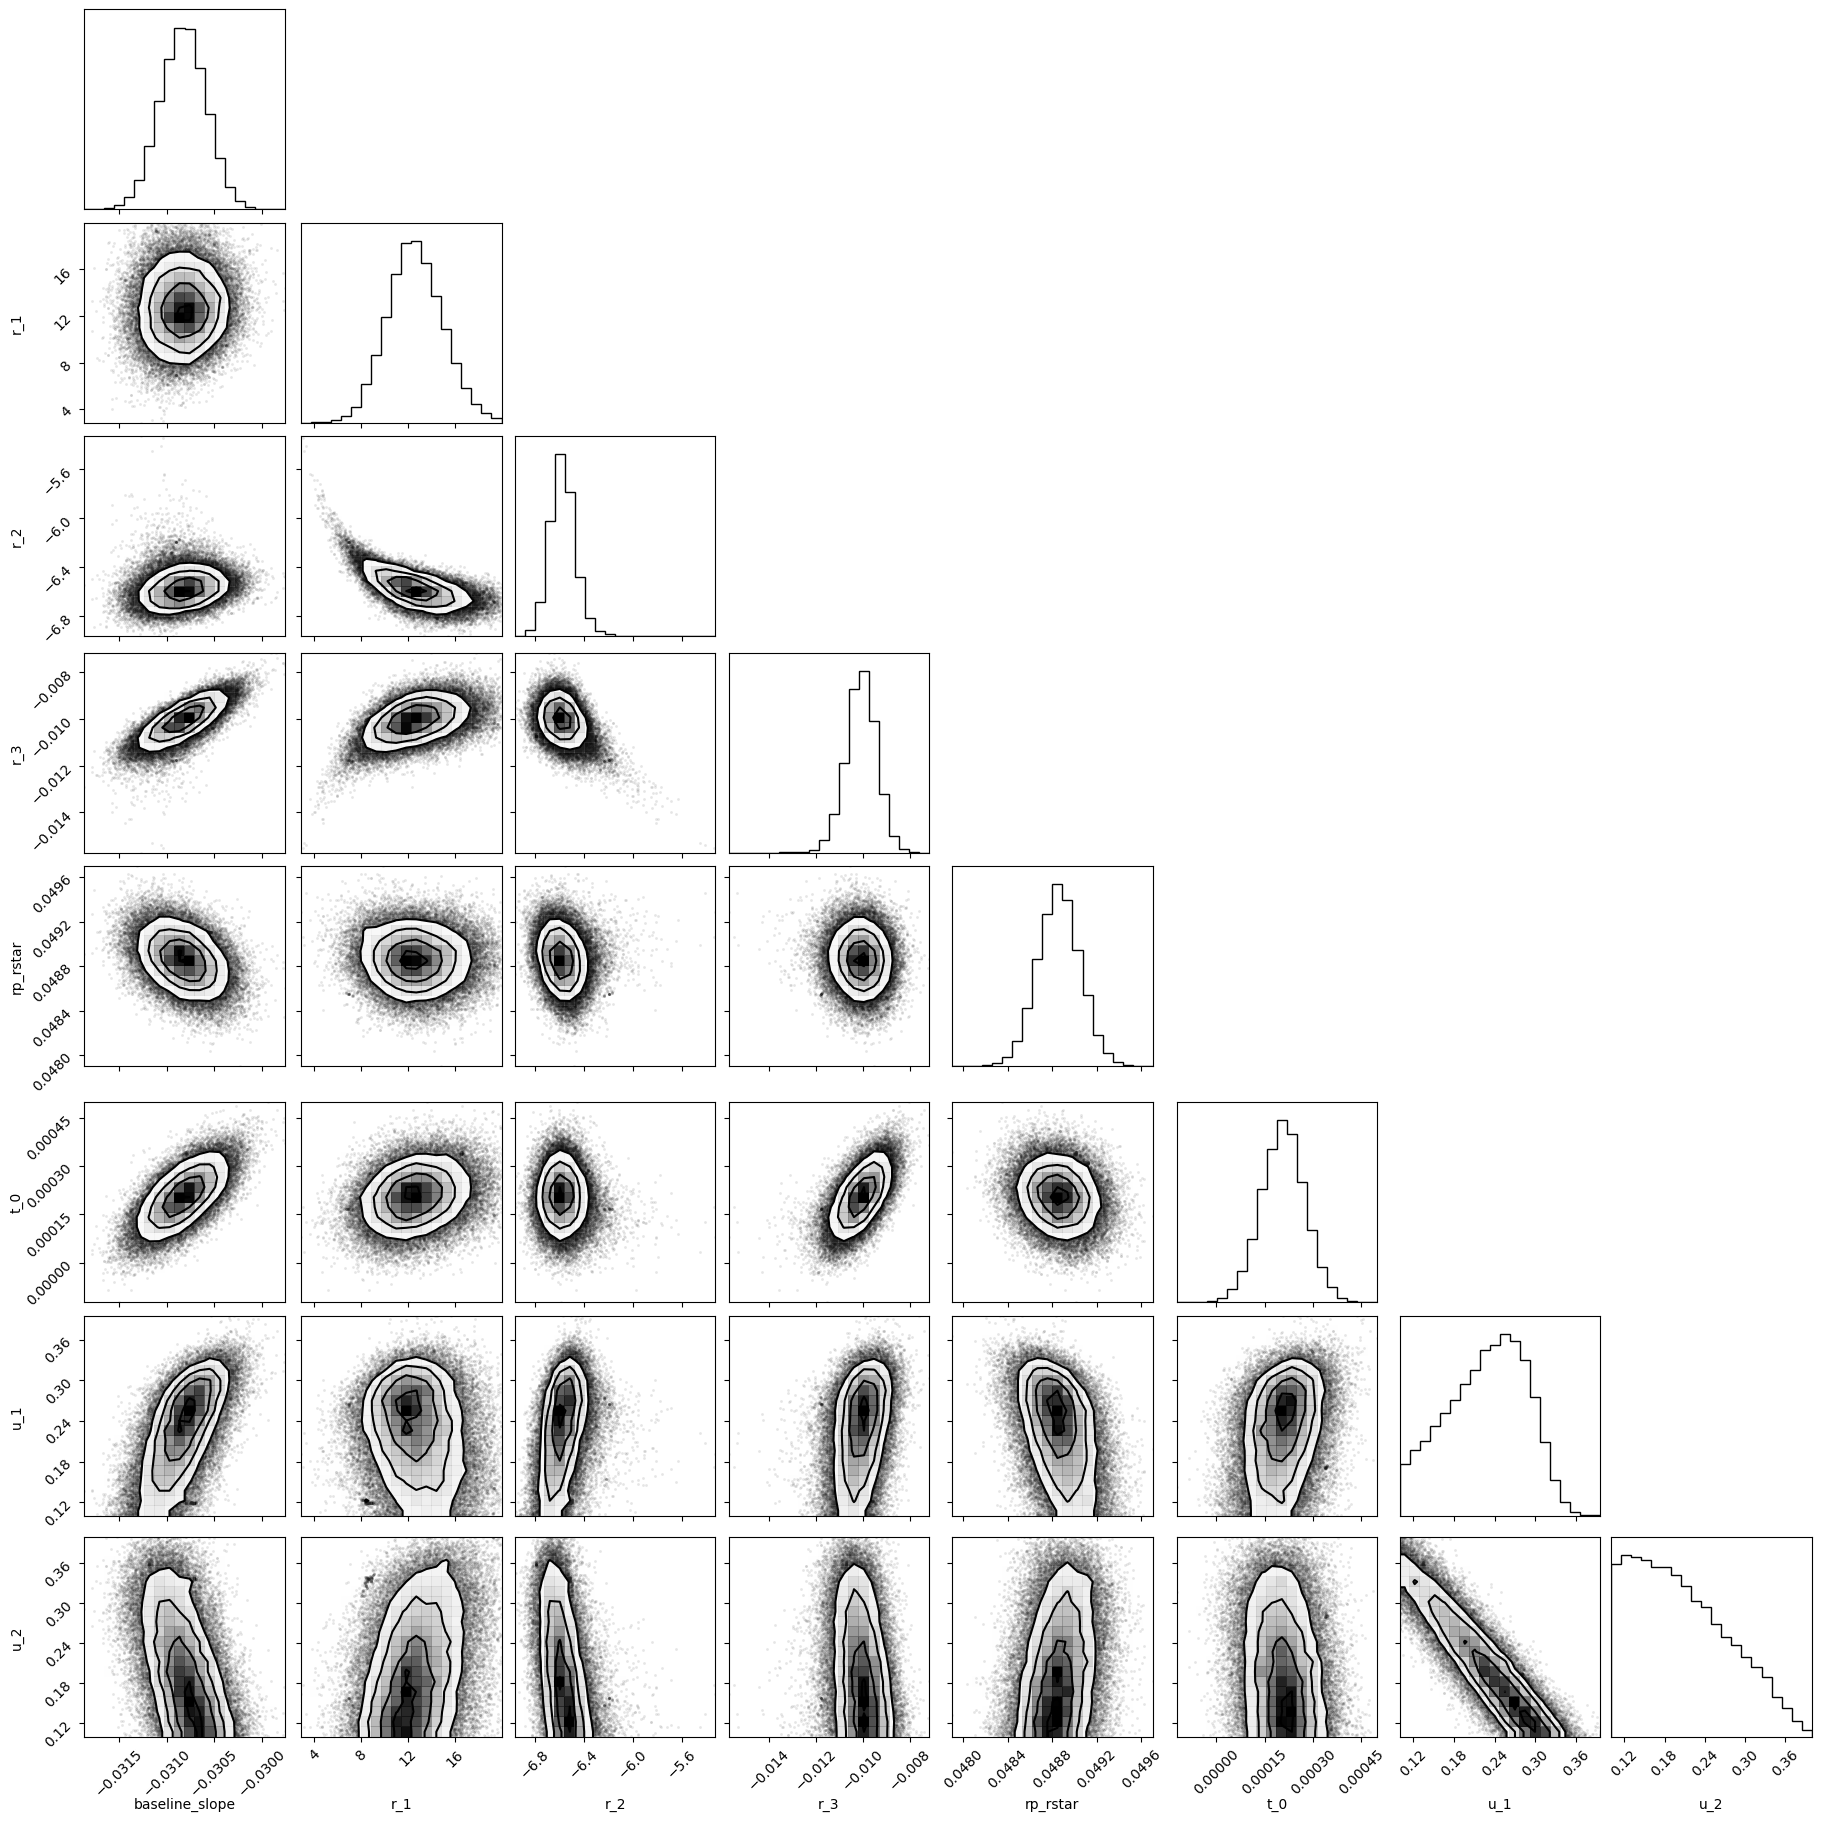

In [27]:
'Make a simpler corner plot'
corner.corner(
    result, 
    var_names=['~beta','~b_1','~b_2','~b_3','~b_4'],
    quiet=False, 
)
plt.savefig(f'../../figs/{model_designation}_corner-simple.png',dpi=200)

In [28]:
result = arviz.from_netcdf(f'../../data/samples/{model_designation}')

latex_summary = az.summary(result)
latex_summary.to_latex(f"../../results/{model_designation}-results-table.tex", float_format="%.6f")

# Create empty DataFrame to store results
results = []

# Compute quantiles for each variable
for var_name in result.posterior.data_vars:
    # Flatten all chains and draws
    samples = result.posterior[var_name].values.flatten()
    
    # Compute quantiles
    q16 = np.quantile(samples, 0.16)
    median = np.quantile(samples, 0.50)
    q84 = np.quantile(samples, 0.84)

    diff_upper = q84-median
    diff_lower = median-q16
    
    results.append({
        'parameter': var_name,
        'q16': q16,
        'median': median,
        'q84': q84,
        'upper_err':diff_upper,
        'lower_err':diff_lower
    })

# Convert to DataFrame
quantile_df = pd.DataFrame(results)
quantile_df = quantile_df.set_index('parameter')

# Save to LaTeX
quantile_df.to_latex(f"../../results/{model_designation}-quantile_results.tex", float_format="%.6f")

## Print and plot the MEDIAN parameter results

b_1               -0.060
b_2                0.187
b_3               -0.218
b_4                0.093
baseline_slope    -0.031
beta               0.135
r_1               12.553
r_2               -6.580
r_3               -0.010
rp_rstar           0.049
t_0                0.000
u_1                0.232
u_2                0.196
Name: median, dtype: float64


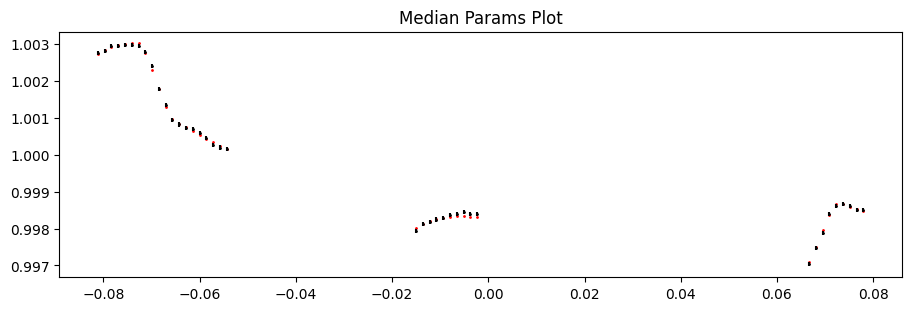

<Figure size 640x480 with 0 Axes>

In [29]:
result = az.from_netcdf(f"../../data/samples/{model_designation}")
final_median_params = arviz.summary(result,stat_focus='median')['median']

final_lc_model, _ = plot_results(final_median_params)

print(final_median_params)

plt.figure(figsize=(9,3))
plt.errorbar(time_from_T0,normalized_data_flux,
             yerr=(10**final_median_params.get('beta', default_params['beta']))*normalized_relative_err,
             fmt='o',ms=1,color='k')
plt.scatter(time_from_T0,final_lc_model,s=1,color='r')
plt.title(f'Median Params Plot')
plt.savefig(f'../../figs/Final_{model_designation}_lc_model.png',dpi=200)
plt.show()
plt.clf()

## Print and plot the Maximum Likelihood Estimate results

In [30]:
# Collect all data first to ensure consistent headers
all_data = []

data_unc = normalized_relative_err
relative_flux = normalized_data_flux

result = arviz.InferenceData.from_netcdf(f'../../data/samples/{model_designation}')

# Extract posterior samples
posterior = result.posterior

# Calculate median and std for all parameters
param_medians = posterior.median()
param_stds = posterior.std()

# Store data for this lc_index
data_entry = {
    'wavelength': fleck_wavelengths[lc_index],
    'params': {}
}

for var_name in posterior.data_vars:
    data_entry['params'][var_name] = {
        'median': float(param_medians[var_name].values),
        'std': float(param_stds[var_name].values)
    }

all_data.append(data_entry)

# Print headers (get param names from first entry)
if all_data:
    param_names = list(all_data[0]['params'].keys())
    
    # Print header
    header = f"{'wavelength':<12}"
    for param in param_names:
        header += f" {param}_median {param}_std"
    print(header)
    
    # Print data rows
    for data in all_data:
        row = f"{data['wavelength']:<12.5f}"
        for param in param_names:
            median_val = data['params'][param]['median']
            std_val = data['params'][param]['std']
            row += f" {median_val:.5f} {std_val:.6f}"
        print(row)

wavelength   b_1_median b_1_std b_2_median b_2_std b_3_median b_3_std b_4_median b_4_std baseline_slope_median baseline_slope_std beta_median beta_std r_1_median r_1_std r_2_median r_2_std r_3_median r_3_std rp_rstar_median rp_rstar_std t_0_median t_0_std u_1_median u_1_std u_2_median u_2_std
1.38750      -0.06008 0.021668 0.18707 0.065274 -0.21773 0.084931 0.09270 0.040462 -0.03083 0.000240 0.13503 0.047727 12.55277 2.373094 -6.57982 0.107844 -0.01006 0.000665 0.04886 0.000188 0.00021 0.000068 0.23235 0.057508 0.19611 0.070202


{'b_1': -0.06558087056895495, 'b_2': 0.2008412749649947, 'b_3': -0.22875703323127017, 'b_4': 0.09456279686297198, 'baseline_slope': -0.031107433639856432, 'beta': 0.12003642140581686, 'r_1': 12.56772504128407, 'r_2': -6.5810069571875065, 'r_3': -0.010655656272698093, 'rp_rstar': 0.049000275340276137, 't_0': 0.00010132913324283565, 'u_1': 0.20670488635464326, 'u_2': 0.19121338887293501}


/var/folders/vq/zxq380ws52q37mjjtbt9c7rh0000gp/T/ipykernel_61727/2078125502.py:172: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


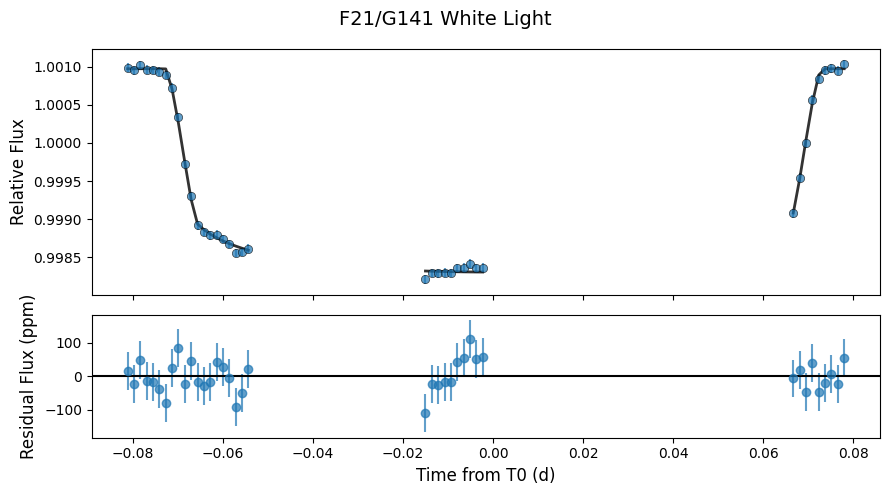

In [36]:
def calculate_model(parameter_dict,relative_flux):
    
    params = parameter_dict

    # Calculate systematics model
    ramp = ramp_model_jax(phase=ramp_phase,
                    r1=jnp.asarray(params.get('r_1',default_params['r_1']), dtype=jnp.float64),
                    r2=jnp.asarray(params.get('r_2',default_params['r_2']), dtype=jnp.float64),
                    r3=jnp.asarray(params.get('r_3',default_params['r_3']), dtype=jnp.float64) )
    breathing = breathing_model_jax(phase=breathing_phase,
                              b1=jnp.asarray(params.get('b_1',default_params['b_1']), dtype=jnp.float64),
                              b2=jnp.asarray(params.get('b_2',default_params['b_2']), dtype=jnp.float64),
                              b3=jnp.asarray(params.get('b_3',default_params['b_3']), dtype=jnp.float64),
                              b4=jnp.asarray(params.get('b_4',default_params['b_4']), dtype=jnp.float64))
    linear_baseline = linear_model_jax(x=time_from_T0,
                                        m=jnp.asarray(params.get('baseline_slope',default_params['baseline_slope']), dtype=jnp.float64),
                                        )
    _systematics = (breathing * ramp * linear_baseline)
    systematics = _systematics/jnp.mean(_systematics)
    
    # Update Planet Parameters
    planet_parameters = dict(
        inclination = jnp.radians(default_params['i_planet']),
        a = jnp.asarray(params.get('a_rstar',default_params['a_rstar']), dtype=jnp.float64),
        rp = jnp.asarray(params.get('rp_rstar',default_params['rp_rstar']), dtype=jnp.float64),
        period = jnp.asarray(params.get('P_orb',default_params['P_orb']), dtype=jnp.float64),
        t0 = jnp.asarray(params.get('t_0',default_params['t_0']), dtype=jnp.float64),
        ecc = jnp.asarray(params.get('ecc',default_params['ecc']), dtype=jnp.float64),
        u1 = jnp.asarray(params.get('u_1',default_params['u_1']), dtype=jnp.float64),
        u2 = jnp.asarray(params.get('u_2',default_params['u_2']), dtype=jnp.float64),
    )
    
    # Get spectra for the model temps
    Phot = get_binned_BTSettl_spectrum_jax(T=jnp.asarray(params.get('T_phot',default_params['T_phot']), dtype=jnp.float64),
                                           data_wave = fleck_wavelengths)
    Cool = get_binned_BTSettl_spectrum_jax(T=jnp.asarray(params.get('T_spot',default_params['T_spot']), dtype=jnp.float64),
                                           data_wave = fleck_wavelengths)
    
    # Update stellar parameters
    active_star = ActiveStar(
        times = time_from_T0,
        inclination = jnp.radians(default_params['i_star']),
        T_eff=jnp.asarray(params.get('T_phot',default_params['T_phot']), dtype=jnp.float64),
        wavelength=Phot[0]*1e-6, # convert from micron to m
        phot=Phot[1],
        P_rot=default_params['P_rot']
    )
    
    active_star.spectrum = jnp.concatenate([
        jnp.vstack([Cool[1],Cool[1],Cool[1]
                   ]),
    ])
    active_star.temperature = jnp.concatenate([
        jnp.array([params.get('T_spot', default_params['T_spot']),
                   params.get('T_spot', default_params['T_spot']),
                   params.get('T_spot', default_params['T_spot'])
                  ]),
    ])
    active_star.lon = jnp.concatenate([
        jnp.array([params.get('limb_spot_lon', default_params['limb_spot_lon']), 
                   params.get('chord_spot_lon_1', default_params['chord_spot_lon_1']), 
                   params.get('chord_spot_lon_2', default_params['chord_spot_lon_2']),
                   ]),
    ])
    active_star.lat = jnp.concatenate([
        jnp.array([params.get('limb_spot_lat', default_params['limb_spot_lat']), 
                   params.get('chord_spot_lat_1', default_params['chord_spot_lat_1']), 
                   params.get('chord_spot_lat_2', default_params['chord_spot_lat_2']),
                   ]),
    ])
    active_star.rad = jnp.concatenate([
        jnp.array([params.get('limb_spot_rad', default_params['limb_spot_rad']), 
                   params.get('chord_spot_rad_1', default_params['chord_spot_rad_1']), 
                   params.get('chord_spot_rad_2', default_params['chord_spot_rad_2']),
                   ]),
    ])
    
    lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)        
    lc_model = lc.T[lc_index] * systematics
    mean_per_wavelength = jnp.mean(lc_model)
    normalized_model = lc_model / mean_per_wavelength
    residuals = relative_flux - normalized_model
    de_trended_model = normalized_model / systematics
    de_trended_data = relative_flux/systematics

    return normalized_model, residuals, de_trended_model/jnp.mean(de_trended_model), de_trended_data/jnp.mean(de_trended_data)


def get_representative_sample_from_dict(posterior_dict_entry):
    """
    Works with the posterior dict structure you have.
    
    Parameters:
    -----------
    posterior_dict_entry : xarray Dataset
        The value from your posterior_samples dict (posterior_samples[lc_index])
    method : str
        'median' : Sample closest to medians (recommended)
    """
    # Extract the actual posterior dataset
    posterior_dataset = posterior_dict_entry
    
    # Get median values
    medians = posterior_dataset.median()
    
    # Get parameter names
    param_names = list(posterior_dataset.data_vars)
    
    # Prepare arrays
    all_samples = []
    median_values = []
    
    for param in param_names:
        # Get samples for this parameter (flatten chains and draws)
        samples = posterior_dataset[param].values.flatten()
        all_samples.append(samples)
        
        # Get median value
        median_values.append(float(medians[param]))
    
    # Convert to arrays
    param_matrix = np.column_stack(all_samples)  # n_samples x n_params
    median_array = np.array(median_values)       # n_params
    
    # Find sample closest to medians
    distances = np.linalg.norm(param_matrix - median_array, axis=1)
    closest_idx = np.argmin(distances)
    
    # Build representative parameter dict
    representative_params = {}
    for i, param in enumerate(param_names):
        representative_params[param] = param_matrix[closest_idx, i]
    
    return representative_params

def plot_final_lightcurve(jax_flux, jax_rel_err, time_from_T0, 
                           posterior_samples_dict, designation):
    
    fig, (ax_lc, ax_res) = plt.subplots(2, 1, figsize=(9, 5), sharex=True,height_ratios=[1,0.5])
    
    # Get median model for this light curve
    param_medians = get_representative_sample_from_dict(posterior_samples_dict[0])
    print(param_medians)
    _, residuals, median_model, detrended_relative_flux = calculate_model(param_medians, jax_flux)

    # Plot light curve with offset on left panel
    ax_lc.errorbar(time_from_T0, detrended_relative_flux-0.00045,
                    yerr=jax_rel_err*detrended_relative_flux, fmt='o', alpha=0.7,
                    # color='blue',
                    markeredgecolor='k', markeredgewidth=0.5)
    
    # Plot median model on left panel
    ax_lc.plot(time_from_T0[0:20], median_model[0:20]-0.00045, '-', 
                color='k', linewidth=2, alpha=0.8)
    ax_lc.plot(time_from_T0[20:30], median_model[20:30]-0.00045, '-', 
                color='k', linewidth=2, alpha=0.8)
    ax_lc.plot(time_from_T0[30:], median_model[30:]-0.00045, '-', 
                color='k', linewidth=2, alpha=0.8)
    
    ax_res.errorbar(time_from_T0, residuals*1e6, 
                    yerr=jax_rel_err*1e6, fmt='o',
                    alpha=0.7)
    ax_res.axhline(0,color='k')
    
    # Set labels and formatting for LEFT panel
    ax_lc.set_ylabel('Relative Flux', fontsize=12)
    ax_res.set_ylabel('Residual Flux (ppm)', fontsize=12)
    ax_res.set_xlabel('Time from T0 (d)', fontsize=12)
    # ax_res.set_xlim(-0.09,0.09)
    fig.suptitle('F21/G141 White Light',fontsize=14)

    fig.tight_layout()
    
    # Save figure
    plt.savefig(f'../../figs/{model_designation}_whitelight.png', dpi=400)
    plt.show()
    
posterior_samples = {}
result = arviz.InferenceData.from_netcdf(f'../../data/samples/{model_designation}')
posterior_samples[0] = result.posterior

# Create scaling factors array
scaling_factor = jnp.array([
    10**float(posterior_samples[0]['beta'].median().values)
])

jax_rel_err = scaling_factor * normalized_relative_err
jax_flux = normalized_data_flux

# Plot the mosaic
plot_final_lightcurve(jax_flux, jax_rel_err, time_from_T0,
    posterior_samples, model_designation)